# This example comes from
https://github.com/adjtomo/adjdocs/blob/main/workshops/2024-05-21_scoped_uw/3_adjoint_simulations.ipynb

In [2]:
# Python packages we will use in this notebook
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image
from scipy.integrate import simpson
np.float_ = np.float64
from seisflows.tools.model import Model 
from pyatoa import Config, Manager, logger
from pysep.utils.io import read_sem

In [3]:
# Make correct dir. and move there
! mkdir -p /home/scoped/work/kernels
%cd /home/scoped/work/kernels

# Symlink the executables and copy the relevant DATA/ directory
! ln -s /home/scoped/specfem2d/bin .
! cp -r /home/scoped/specfem2d/EXAMPLES/Tape2007/DATA .
! mkdir OUTPUT_FILES

! ls

/home/scoped/work/kernels
ln: failed to create symbolic link './bin': File exists
mkdir: cannot create directory ‘OUTPUT_FILES’: File exists
AA.S000000.BXY.png  DATA	  OUTPUT_FILES_INIT  SEM
bin		    OUTPUT_FILES  OUTPUT_FILES_TRUE


In [4]:
# Incase participants get lost, each numbered section 
# contains the absolute work dir path
%cd /home/scoped/work/kernels

/home/scoped/work/kernels


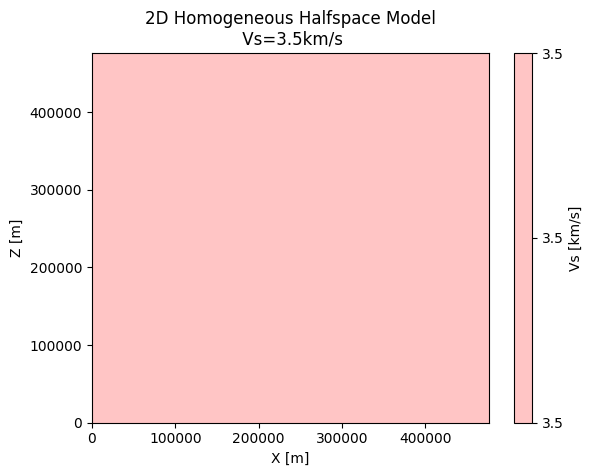

In [5]:
def plot_homogeneous_halfspace():
    """
    Plots a representation of the SPECFEM2D 
    homogeneous halfspace model
    """
    # Sets the X and Z dimensions of our mesh
    x = np.arange(0, 480000, 4000)
    z = np.arange(0, 480000, 4000)
    
    # Reformat the 1D arrays into 2D
    xv, zv = np.meshgrid(x, z)

    # Set a homogeneous value of Vs=3.5km/s 
    vs = 3.5 * np.ones(np.shape(xv))

    # Plot the arrays as a homogeneous halfspace
    plt.tricontourf(xv.flatten(), zv.flatten(), vs.flatten(), 
                    cmap="seismic_r", vmin=3.1, vmax=4.)
    plt.colorbar(label="Vs [km/s]", format="%.1f")
    plt.xlabel("X [m]")
    plt.ylabel("Z [m]")
    plt.title("2D Homogeneous Halfspace Model\n Vs=3.5km/s")
    
# Calls the function we just defined
plot_homogeneous_halfspace()

In [16]:
# Look at the first few lines of the checkerboard model
! head DATA/model_velocity.dat_checker

	0	    0.0000	    0.0000	2600.0000	5800.0000	3500.0000
	1	 2072.1000	    0.0000	2600.0000	5800.0000	3500.0000
	2	 6000.0000	    0.0000	2600.0000	5800.0000	3500.0000
	3	 9927.9000	    0.0000	2600.0000	5800.0000	3500.0000
	4	12000.0000	    0.0000	2600.0000	5800.0000	3500.0000
	5	    0.0000	 2072.1000	2600.0000	5800.0000	3500.0000
	6	 2072.1000	 2072.1000	2600.0000	5800.3000	3500.3000
	7	 6000.0000	 2072.1000	2600.0000	5800.8000	3501.0000
	8	 9927.9000	 2072.1000	2600.0000	5801.3000	3501.6000
	9	12000.0000	 2072.1000	2600.0000	5801.6000	3501.9000


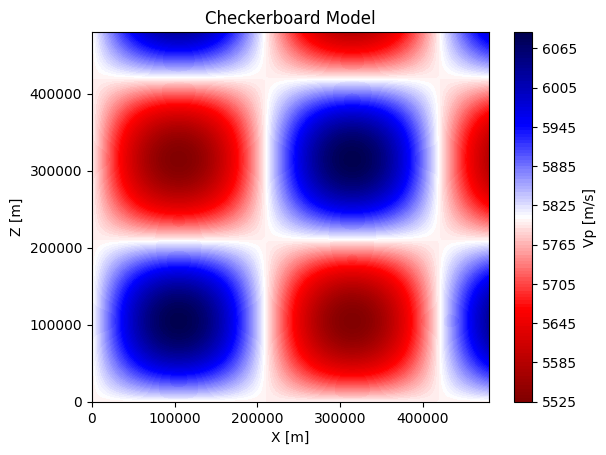

In [7]:
# Grab values of X, Z, Vs and Vp for plotting
chkbd_x, chkbd_z, chkbd_vp, chkbd_vs = np.genfromtxt("DATA/model_velocity.dat_checker", dtype=float, usecols=[1,2,4,5]).T

def plot_checkerboard(x, z, c, label, alpha=1):
    """Simple re-usable model plotting function"""
    plt.tricontourf(x, z, c, levels=125, cmap="seismic_r", alpha=alpha)
    plt.xlabel("X [m]")
    plt.ylabel("Z [m]")
    plt.title("Checkerboard Model")
    plt.colorbar(label=label)
    
plot_checkerboard(chkbd_x, chkbd_z, chkbd_vp, label="Vp [m/s]")



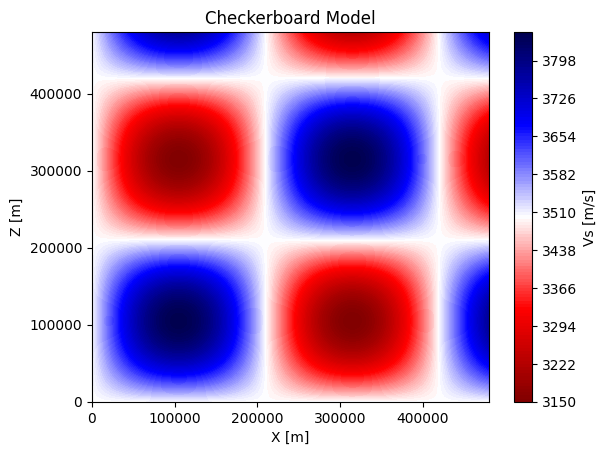

In [8]:

plot_checkerboard(chkbd_x, chkbd_z, chkbd_vs, label="Vs [m/s]")

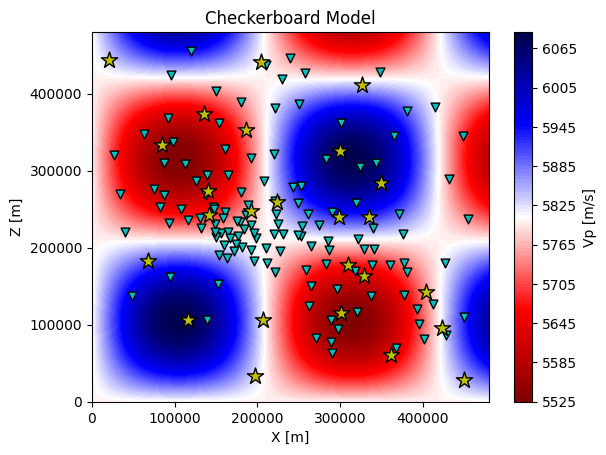

In [9]:
# Grab coordinates from STATIONS file
sta_x, sta_z = np.genfromtxt("DATA/STATIONS_checker", dtype=float, usecols=[2, 3]).T

# Grab coordinates from SOURCE files
ev_x, ev_z = [], []
for i in range(1, 26):
    source_file = f"DATA/SOURCE_{i:0>3}"
    with open(source_file, "r") as f:
        lines = f.readlines()
    # Trying to break apart the following line
    # 'xs = 299367.72      # source location x in meters\n'
    xs = float(lines[2].split("=")[1].split("#")[0].strip())
    zs = float(lines[3].split("=")[1].split("#")[0].strip())
    
    ev_x.append(xs)
    ev_z.append(zs)
    
# Plot SOURCES and STATIONS on top of the checkerboard model
plot_checkerboard(chkbd_x, chkbd_z, chkbd_vp, label="Vp [m/s]")
plt.scatter(sta_x, sta_z, c="c", marker="v", s=40, edgecolor="k")
plt.scatter(ev_x, ev_z, c="y", marker="*", s=150, edgecolor="k")

Text(0.5, 1.0, 'SOURCES; N=25')

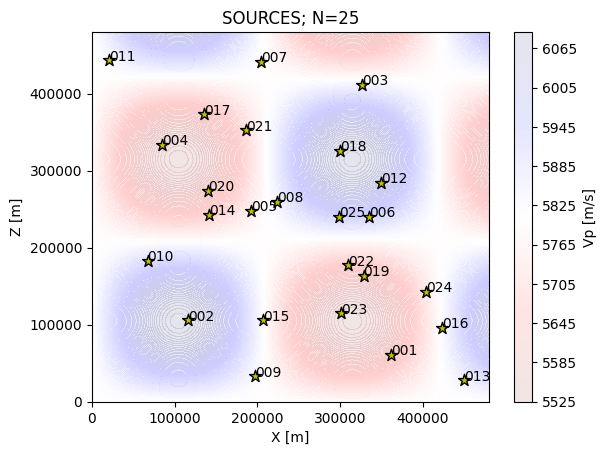

In [10]:
# Plot SOURCES next to source names
plot_checkerboard(chkbd_x, chkbd_z, chkbd_vp, label="Vp [m/s]", alpha=0.1)

for i, (x, z) in enumerate(zip(ev_x, ev_z)):
    plt.scatter(x, z, c="y", marker="*", edgecolor="k", s=80)
    plt.text(x, z, f"{i+1:0>3}", c="k")  # SOURCE numbering starts at 1
plt.title(f"SOURCES; N={len(ev_x)}")

Text(0.5, 1.0, 'STATIONS; N=132')

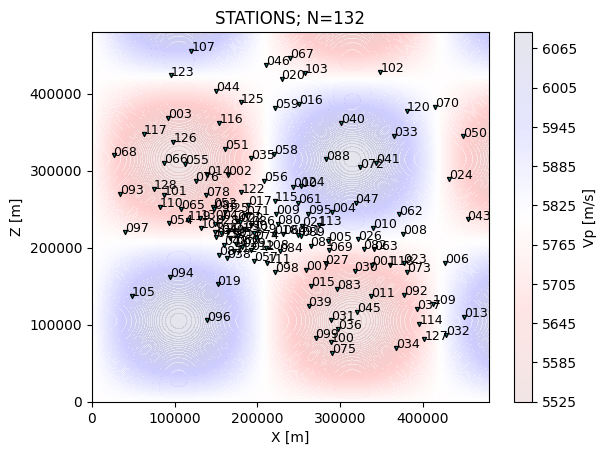

In [11]:
# Plot STATIONS next to source names
plot_checkerboard(chkbd_x, chkbd_z, chkbd_vp, label="Vp [m/s]", alpha=0.1)

for i, (x, z) in enumerate(zip(sta_x, sta_z)):
    plt.scatter(x, z, c="c", marker="v", s=8, edgecolor="k")
    plt.text(x, z, f"{i:0>3}", fontsize=9)
plt.title(f"STATIONS; N={len(sta_x)}")

Text(0.5, 1.0, 'SOURCE 01; STATION 01')

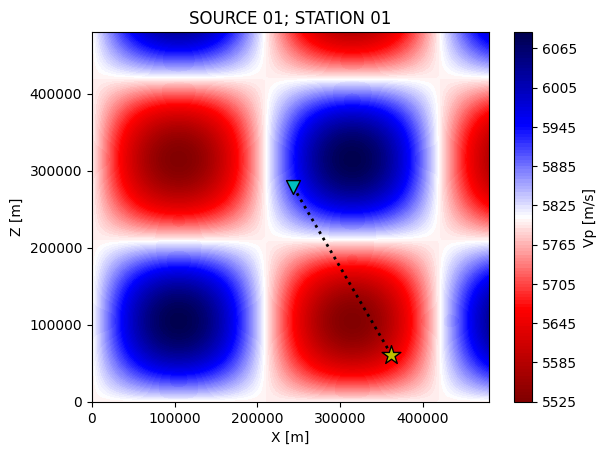

In [12]:
# Plot the experimental setup we'll use for Section 2
plot_checkerboard(chkbd_x, chkbd_z, chkbd_vp, label="Vp [m/s]")

# Plot SOURCE 1, STATION 1 and a connecting line
plt.plot((sta_x[0], ev_x[0]), (sta_z[0], ev_z[0]), c="k", ls=":", lw=2, zorder=1)
plt.scatter(sta_x[0], sta_z[0], c="c", marker="v", s=100, edgecolor="k")
plt.scatter(ev_x[0], ev_z[0], c="y", marker="*", edgecolor="k", s=200)

plt.title(f"SOURCE 01; STATION 01")

In [13]:
%cd /home/scoped/work/kernels

/home/scoped/work/kernels


In [15]:
# We use SOURCE 1 as our preferred event
! cp -f DATA/SOURCE_001 DATA/SOURCE

# We take the first line of the STATIONS file as our single station
! head -1 DATA/STATIONS_checker > DATA/STATIONS

# Copy the Parameter file and make some adjustments 
! cp -f DATA/Par_file_Tape2007_132rec_checker DATA/Par_file

# Set parameters 
! seisflows sempar -P DATA/Par_file NSTEP 5000  # to match homogeneous halfspace Par_file
! seisflows sempar -P DATA/Par_file save_model binary
! seisflows sempar -P DATA/Par_file setup_with_binary_database 1

# Ensure that SPECFEM can find the checkerboard model by naming it correctly
! cp -f DATA/model_velocity.dat_checker DATA/proc000000_model_velocity.dat_input

# Run Meshfem and SPECFEM SPECFEM2D 
! mpirun -n 1 bin/xmeshfem2D > OUTPUT_FILES/output_mesher.txt
! mpirun -n 1 bin/xspecfem2D > OUTPUT_FILES/output_solver.txt

# Rename the OUTPUT_FILES so that our next run doesn't overwrite files
! mv OUTPUT_FILES OUTPUT_FILES_TRUE

# Print the log message when the simulation is finished
! tail OUTPUT_FILES_TRUE/output_solver.txt

NSTEP: 4800 -> 5000
SAVE_MODEL: default -> binary
setup_with_binary_database: 0 -> 1
mv: cannot move 'OUTPUT_FILES' to 'OUTPUT_FILES_TRUE/OUTPUT_FILES': File exists
 -------------------------------------------------------------------------------
 Program SPECFEM2D: 
 -------------------------------------------------------------------------------
 -------------------------------------------------------------------------------
 Tape-Liu-Tromp (GJI 2007)
 -------------------------------------------------------------------------------
 -------------------------------------------------------------------------------
 D a t e : 19 - 02 - 2026                                 T i m e  : 00:40:56
 -------------------------------------------------------------------------------
 -------------------------------------------------------------------------------


OUTPUT_FILES_TRUE/AA.S000000.BXY.semd


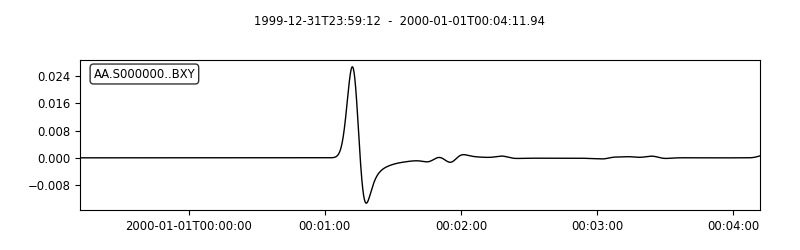

In [16]:
# SPECFEM has generated one synthetic seismogram
! ls OUTPUT_FILES_TRUE/*semd

# We can look at this 'data' waveform using SeisFlows plot
! seisflows plotst OUTPUT_FILES_TRUE/AA.S000000.BXY.semd --savefig AA.S000000.BXY.png
Image("AA.S000000.BXY.png")

In [17]:
# The SOURCE and STATIONS files should remain the same,
# we only want to tell SPECFEM to use the homogeneous halfspace model
! cp -f DATA/Par_file_Tape2007_onerec DATA/Par_file

# Set some Par_file parameters to match the previous run
! seisflows sempar -P DATA/Par_file use_existing_stations .true.
! seisflows sempar -P DATA/Par_file save_model binary
! seisflows sempar -P DATA/Par_file setup_with_binary_database 1
! seisflows sempar -P DATA/Par_file save_forward .true.

# Run SPECFEM with the homogeneous halfspace model, defined in the Par_file
! rm -r OUTPUT_FILES
! mkdir OUTPUT_FILES
! mpirun -n 1 bin/xmeshfem2D > OUTPUT_FILES/output_mesher.txt
! mpirun -n 1 bin/xspecfem2D > OUTPUT_FILES/output_solver.txt

# Copy the OUTPUT_FILES so that our subsequent run doesn't overwrite files
# We do this because the adjoint simulation will require DATABASE files located within
! cp -r OUTPUT_FILES OUTPUT_FILES_INIT

# Print the log message when the simulation is finished
! tail OUTPUT_FILES_INIT/output_solver.txt

use_existing_STATIONS: .false. -> .true.
SAVE_MODEL: default -> binary
setup_with_binary_database: 0 -> 1
SAVE_FORWARD: .false. -> .true.
rm: cannot remove 'OUTPUT_FILES': No such file or directory
 -------------------------------------------------------------------------------
 Program SPECFEM2D: 
 -------------------------------------------------------------------------------
 -------------------------------------------------------------------------------
 Tape-Liu-Tromp (GJI 2007)
 -------------------------------------------------------------------------------
 -------------------------------------------------------------------------------
 D a t e : 19 - 02 - 2026                                 T i m e  : 00:41:41
 -------------------------------------------------------------------------------
 -------------------------------------------------------------------------------


In [18]:
# Look at the resulting outputs of the `save_forward` parameter
! diff -qr OUTPUT_FILES_INIT/ OUTPUT_FILES_TRUE/ | grep 'Only'

Only in OUTPUT_FILES_INIT/: absorb_elastic_bottom000000.bin
Only in OUTPUT_FILES_INIT/: absorb_elastic_left000000.bin
Only in OUTPUT_FILES_INIT/: absorb_elastic_right000000.bin
Only in OUTPUT_FILES_INIT/: absorb_elastic_top000000.bin
Only in OUTPUT_FILES_INIT/: lastframe_elastic000000.bin


OUTPUT_FILES_INIT/AA.S000000.BXY.semd


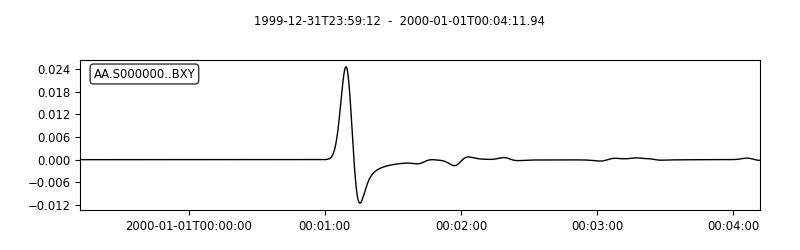

In [19]:
# Again we can look at the waveform. We will compare in the next section
! ls OUTPUT_FILES_INIT/*semd

! seisflows plotst OUTPUT_FILES_INIT/AA.S000000.BXY.semd --savefig AA.S000000.BXY.png
Image("AA.S000000.BXY.png")

In [20]:
! head OUTPUT_FILES/AA.S000000.BXY.semd

  -48.000000000000000          0.0000000000000000     
  -47.939999999999998          0.0000000000000000     
  -47.880000000000003          0.0000000000000000     
  -47.820000000000000          0.0000000000000000     
  -47.759999999999998          0.0000000000000000     
  -47.700000000000003          0.0000000000000000     
  -47.640000000000001          0.0000000000000000     
  -47.579999999999998          0.0000000000000000     
  -47.520000000000003          0.0000000000000000     
  -47.460000000000001          0.0000000000000000     


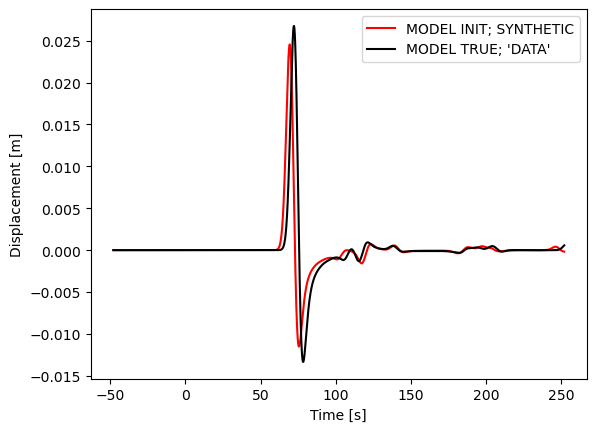

In [21]:
# Read in the two-column ASCII files using NumPy where - t=time; d=data
t_init, d_init = np.loadtxt("OUTPUT_FILES_INIT/AA.S000000.BXY.semd").T
t_true, d_true = np.loadtxt("OUTPUT_FILES_TRUE/AA.S000000.BXY.semd").T

# Plot both waveforms using Matplotlib
plt.plot(t_init, d_init, c="r", label="MODEL INIT; SYNTHETIC")
plt.plot(t_true, d_true, c="k", label="MODEL TRUE; 'DATA'")
plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.legend()
plt.show()

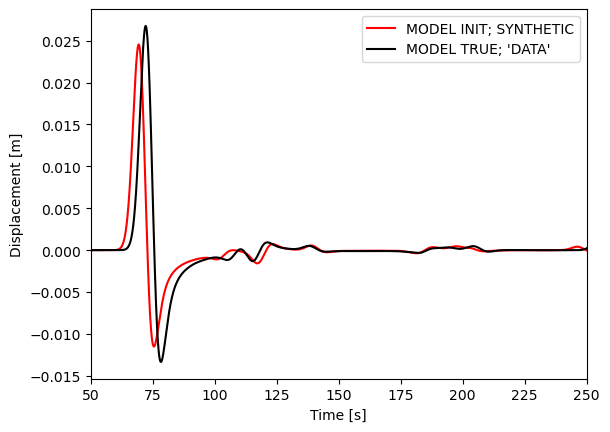

In [22]:
# Zoom in on waveform figure ignoring T<50s
plt.plot(t_init, d_init, c="r", label="MODEL INIT; SYNTHETIC")
plt.plot(t_true, d_true, c="k", label="MODEL TRUE; 'DATA'")
plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.xlim((50,250))
plt.legend()
plt.show()

In [23]:
# Integrate using scipy
dt = t_true[1] - t_true[0]  # dt represents the time step
misfit = 1/2 * simpson((d_true - d_init)**2, dx=dt)

print(f"misfit={misfit:.3E}")

misfit=1.453E-03


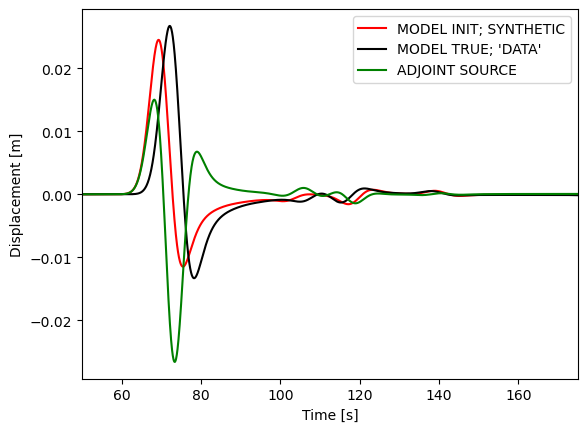

In [24]:
# Calculate the adjoint source using data and synthetic
d_adj = d_init - d_true

# Plot both waveforms using Matplotlib
plt.plot(t_init, d_init, c="r", label="MODEL INIT; SYNTHETIC")
plt.plot(t_true, d_true, c="k", label="MODEL TRUE; 'DATA'")
plt.plot(t_init, d_adj, c="g", label="ADJOINT SOURCE")
plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.xlim([50, 175])
plt.legend()
plt.show()

In [25]:
%cd /home/scoped/work/kernels

/home/scoped/work/kernels


In [26]:
# Make the requisite SEM/ directory
! mkdir SEM/

# Generate the two-column (time, data) format required
adjoint_source = np.vstack((t_init, d_adj)).T

# Save the .adj file as an ASCII file
np.savetxt("SEM/AA.S000000.BXY.adj", adjoint_source)
! head SEM/AA.S000000.BXY.adj

-4.800000000000000000e+01 0.000000000000000000e+00
-4.793999999999999773e+01 0.000000000000000000e+00
-4.788000000000000256e+01 0.000000000000000000e+00
-4.782000000000000028e+01 0.000000000000000000e+00
-4.775999999999999801e+01 0.000000000000000000e+00
-4.770000000000000284e+01 0.000000000000000000e+00
-4.764000000000000057e+01 0.000000000000000000e+00
-4.757999999999999829e+01 0.000000000000000000e+00
-4.752000000000000313e+01 0.000000000000000000e+00
-4.746000000000000085e+01 0.000000000000000000e+00


In [27]:
# Set the parameter file for an adjoint simulation
! seisflows sempar -P DATA/Par_file simulation_type 3
! seisflows sempar -P DATA/Par_file save_ASCII_kernels .false.

! mpirun -n 1 bin/xspecfem2D > OUTPUT_FILES/output_adjsolver.txt

# The adjoint solver also produces an informative log file
! tail OUTPUT_FILES/output_adjsolver.txt

# We can check this was an adjoint simulation because SPECFEM considers adjoint sources
! echo
! head -347 OUTPUT_FILES/output_adjsolver.txt | tail -n 5

SIMULATION_TYPE: 1 -> 3
save_ASCII_kernels: .true. -> .false.
 -------------------------------------------------------------------------------
 Program SPECFEM2D: 
 -------------------------------------------------------------------------------
 -------------------------------------------------------------------------------
 Tape-Liu-Tromp (GJI 2007)
 -------------------------------------------------------------------------------
 -------------------------------------------------------------------------------
 D a t e : 19 - 02 - 2026                                 T i m e  : 00:44:21
 -------------------------------------------------------------------------------
 -------------------------------------------------------------------------------


 adjoint sources:
   adjoint source type:           1
   reading ASCII adjoint source files
   number of adjoint sources =            1


In [28]:
# Copy over the Model files so SeisFlows has access to coordinate information
! cp -r DATA/*.bin OUTPUT_FILES

# Rename alpha and beta kernels
! cp OUTPUT_FILES/proc000000_alpha_kernel.bin OUTPUT_FILES/proc000000_vp_kernel.bin 
! cp OUTPUT_FILES/proc000000_beta_kernel.bin OUTPUT_FILES/proc000000_vs_kernel.bin 

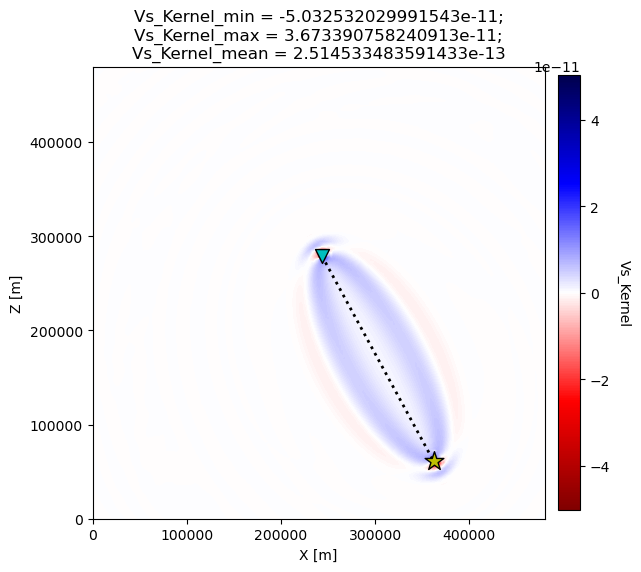

In [29]:
# Use SeisFlows to visualize the kernel
m = Model(path="OUTPUT_FILES")
m.plot2d("vs_kernel", show=False)

# NOTE: The below code snippet is repeated from Section 1, make sure that has been run
# Plot SOURCE 1, STATION 1 and a connecting line
plt.plot((sta_x[0], ev_x[0]), (sta_z[0], ev_z[0]), c="k", ls=":", lw=2, zorder=1)
plt.scatter(sta_x[0], sta_z[0], c="c", marker="v", s=100, edgecolor="k")
plt.scatter(ev_x[0], ev_z[0], c="y", marker="*", edgecolor="k", s=200)

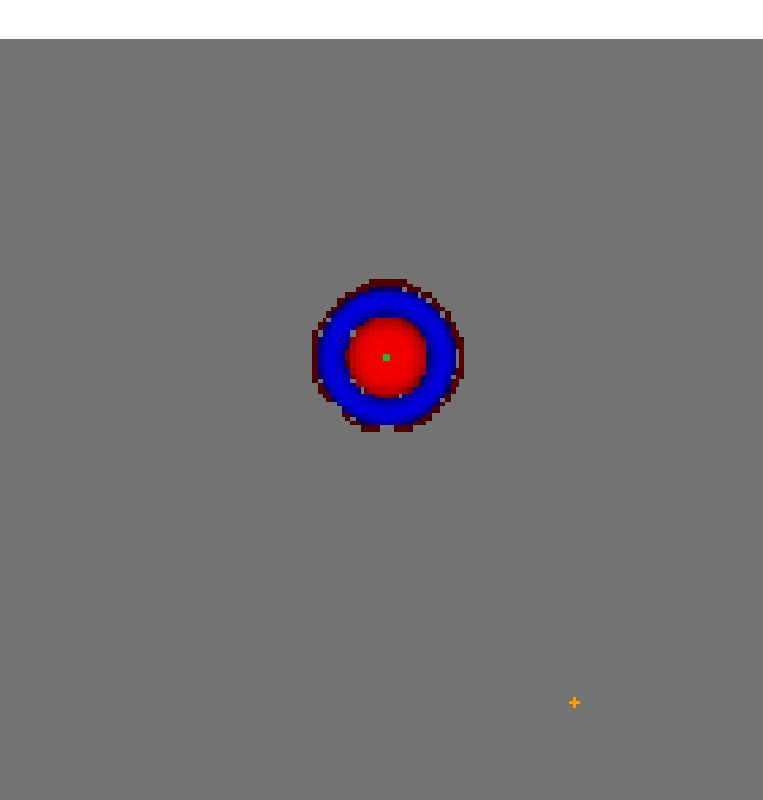

In [30]:
Image("OUTPUT_FILES/adjoint_image000000200.jpg")

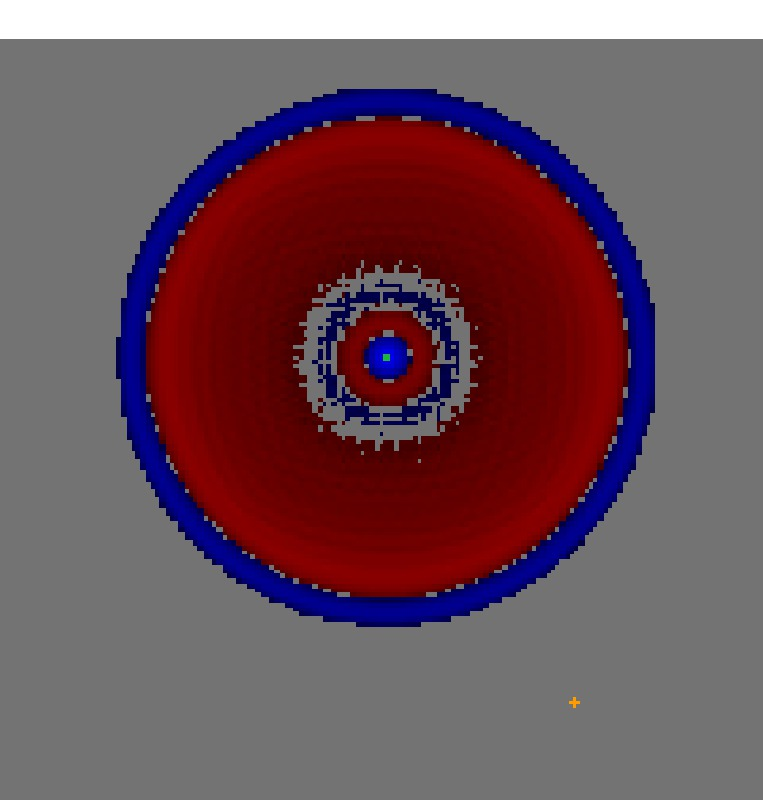

In [31]:
Image("OUTPUT_FILES/adjoint_image000000800.jpg")

 Running XSMOOTH_SEM on           1 processors
 command line arguments:
   smoothing sigma_h , sigma_v                :    5000.00000       5000.00000    
   smoothing scalelengths horizontal, vertical:    14142.1357       14142.1357    
   input dir : OUTPUT_FILES/
   output dir: OUTPUT_FILES/


 Scaling values: min/max =    39263216.0       157106752.    
 written: OUTPUT_FILES//proc000000_vs_kernel_smooth.bin

  Min / Max data value before smoothing =    5.33470852E-19   5.03253203E-11 for vs_kernel
  Min / Max data value after smoothing  =    4.77881162E-19   6.47305820E-12 for vs_kernel
 Computation time with CPU:   17.9555626    
OUTPUT_FILES/proc000000_alpha_kernel.bin
OUTPUT_FILES/proc000000_beta_kernel.bin
OUTPUT_FILES/proc000000_bulk_beta_kernel.bin
OUTPUT_FILES/proc000000_bulk_c_kernel.bin
OUTPUT_FILES/proc000000_kappa_kernel.bin
OUTPUT_FILES/proc000000_mu_kernel.bin
OUTPUT_FILES/proc000000_rho_kernel.bin
OUTPUT_FILES/proc000000_rhop_kernel.bin
OUTPUT_FILES/proc000000_vp_ker

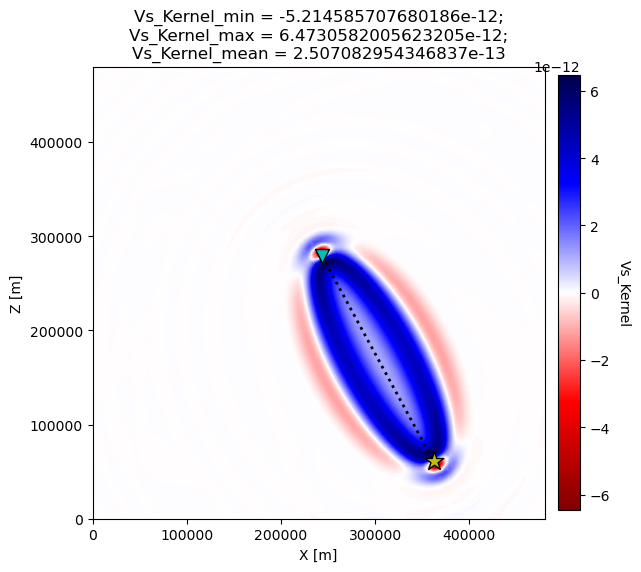

In [32]:

# Run the smoothinig operation
! mpirun -n 1 bin/xsmooth_sem 5000 5000 vs_kernel OUTPUT_FILES/ OUTPUT_FILES/ .false.

# Smoothed kernels are renamed <KERNEL_NAMEL>_smooth
! ls OUTPUT_FILES/*kernel*.bin

# Rename kernel files so we can plot the smooth version with SeisFlows
! mv OUTPUT_FILES/proc000000_vs_kernel.bin OUTPUT_FILES/proc000000_vs_kernel_raw.bin
! mv OUTPUT_FILES/proc000000_vs_kernel_smooth.bin OUTPUT_FILES/proc000000_vs_kernel.bin

# Use SeisFlows to visualize the kernel
m = Model("OUTPUT_FILES")
m.plot2d("vs_kernel", show=False)

# Plot source and receiver on the kernel figure
plt.plot((sta_x[0], ev_x[0]), (sta_z[0], ev_z[0]), c="k", ls=":", lw=2, zorder=1)
plt.scatter(sta_x[0], sta_z[0], c="c", marker="v", s=100, edgecolor="k")
plt.scatter(ev_x[0], ev_z[0], c="y", marker="*", edgecolor="k", s=200)